# Лабораторна робота №2
## Чисельне розв'язання рівняння Бюргерса

Параметри: $\beta=\gamma=1$, $T=50$, $\ell=100$, $h=1$, $\tau=0.01$ (зменшений крок для стабільності ДС; номінал у умові --- $1/3$).

**Methods implemented in this notebook:**
- **DS (alternating direction)** — symmetrized explicit/implicit scheme from burgers.pdf
- **Implicit $\sigma=1/2$** — one-step weighted scheme (dis.pdf eq. 2.3) + Newton + Thomas
- **Forward PINN** — physics-informed neural network (TensorFlow + PhiFlow), [PBDL tutorial](https://physicsbaseddeeplearning.org/physicalloss-code.html)
- **Inverse PINN** (optional) — trainable diffusion coefficient $\gamma$ recovered from sparse data + physics (`burgers_pinn.train_inverse_pinn`)


## 1. Постановка


In [1]:
# FDM stack: numpy + matplotlib + sympy (symbolic PDE check)
# PINN stack: tensorflow + phiflow — imported later in section 7
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Ensure lr2/ is on sys.path whether the notebook runs from lr2/ or lr2/figures/
ROOT = os.path.abspath(
    os.path.join(os.getcwd(), '..') if os.path.basename(os.getcwd()) == 'figures' else '.'
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# FDM helpers: grid, exact u*, DS step, implicit step, norms, run_solver
from burgers_fdm import *


## 2. Аналітичний розв'язок


Symbolic Burgers residual for u*: 0
t=0: min=1.000 max=2.000 u(0)=2.000 u(L)=1.000  (front x=2t=0)
t=16.6667: min=1.000 max=3.000 u(0)=3.000 u(L)=1.000  (front x=2t=33.3333)
t=33.3333: min=1.000 max=3.000 u(0)=3.000 u(L)=1.000  (front x=2t=66.6667)
t=50: min=2.000 max=3.000 u(0)=3.000 u(L)=2.000  (front x=2t=100)


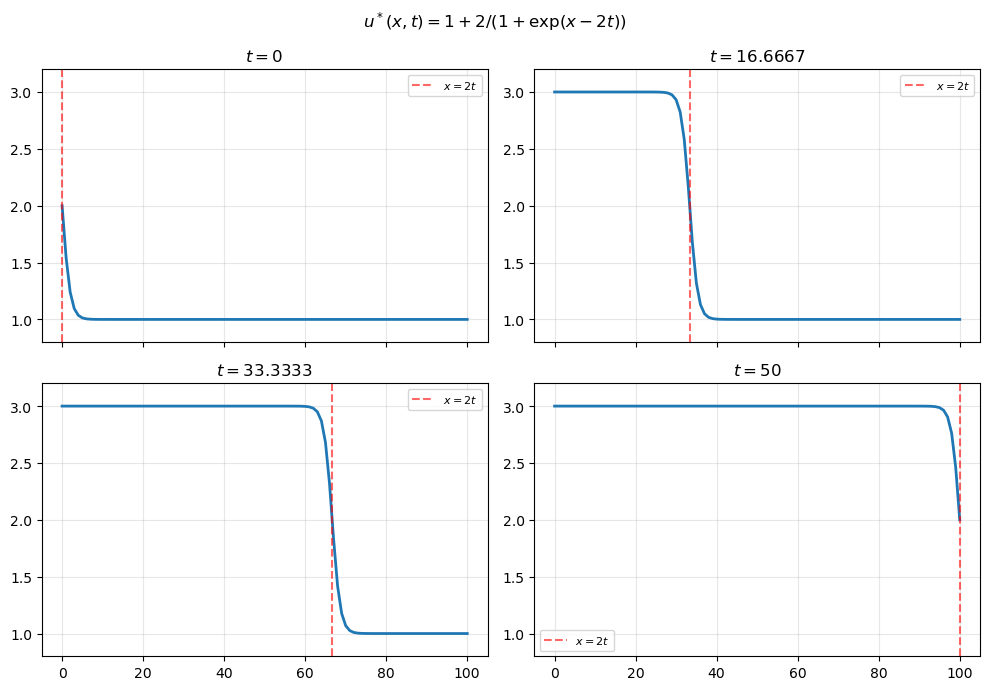

In [2]:
# Exact traveling-wave solution from the lab assignment:
# u*(x,t) = u02 + (u01-u02) / (1 + exp((u01-u02)*(x - c*t) / (2*gamma)))
# => u*(x,t) = 1 + 2 / (1 + exp(x - 2*t))  with u01=3, u02=1, c=2, gamma=1
x, N = build_grid()
t_sym, x_sym = sp.symbols('t x', real=True)
u01, u02, beta, gamma = 3, 1, 1, 1
c = (u01 + u02) / 2
u_star = u02 + (u01 - u02) / (1 + sp.exp((u01 - u02) * (x_sym - c * t_sym) / (2 * gamma)))
res = sp.simplify(sp.diff(u_star, t_sym) + beta * u_star * sp.diff(u_star, x_sym) - gamma * sp.diff(u_star, x_sym, 2))
print('Symbolic Burgers residual for u*:', res)

# Sanity check: wave in [1,3], front x = 2*t
for tp in [0, T_FINAL / 3, 2 * T_FINAL / 3, T_FINAL]:
    u = u_exact(x, tp)
    print(f't={tp:g}: min={u.min():.3f} max={u.max():.3f} u(0)={u[0]:.3f} u(L)={u[-1]:.3f}  (front x=2t={2*tp:g})')

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
for ax, tp in zip(axes.ravel(), [0, T_FINAL / 3, 2 * T_FINAL / 3, T_FINAL]):
    ax.plot(x, u_exact(x, tp), lw=2)
    ax.axvline(2 * tp, color='r', ls='--', alpha=0.6, label=r'$x=2t$')
    ax.set_ylim(0.8, 3.2)
    ax.set_title(f'$t={tp:g}$')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle(r'$u^*(x,t)=1+2/(1+\exp(x-2t))$')
fig.tight_layout()
plt.show()


## 3. Дискретизація


In [3]:
# Grid size and number of time steps for the FDM experiment
print(f'N={N}, tau={TAU}, steps≈{int(T_FINAL/TAU)}')


N=101, tau=0.01, steps≈5000


## 4. Метод 1: ДС-алгоритм


In [4]:
# DS per [1] (4')-(8'): one full step tau; odd/even parity passes
rec = max(1, int(T_FINAL / TAU) // 30)
u_ds, t_ds, h_ds, n_ds, time_ds = run_solver(ds_burgers_step, TAU, T_FINAL, x, record_every=rec)
print(f'DS (paper): steps={n_ds}, time={time_ds:.3f}s')


DS (paper): steps=5001, time=0.322s


## 5. Метод 2: неявна схема


In [5]:
# One-step implicit sigma=0.5 scheme: Newton solves a tridiagonal system each layer
u_im, t_im, h_im, n_im, time_im = run_solver(
    implicit_sigma05_newton_step, TAU, T_FINAL, x, record_every=rec
)
print(f'Implicit sigma=0.5: steps={n_im}, time={time_im:.3f}s')


Implicit sigma=0.5: steps=5001, time=6.181s


## 6. Експерименти FDM


In [6]:
# Error vs reference u*(x, T) at the final time layer
ue = u_exact(x, T_FINAL)
print('Linf DS', norm_linf(u_ds - ue), 'IM', norm_linf(u_im - ue))

# %run figures/_make_figures.py


Linf DS 0.08878200531061298 IM 0.09193591075921193


## 7. PINN (TensorFlow + PhiFlow)

**Forward PINN** (see `burgers_pinn.py`):
- MLP `network(x,t)` with 8×20 tanh layers
- Physics residual `f = u_t + beta*u*u_x - gamma*u_xx` via PhiFlow `gradients`
- Loss: `loss_u` (IC + Dirichlet BC) + `ph_factor * loss_ph` (collocation)
- Optimizer: `GradientDescentOptimizer(lr=0.02)`, fresh random samples each step

**Inverse PINN** (section 7b below):
- Trainable scalar `gamma_est` (initialized e.g. at 0.5 instead of true 1.0)
- Adds sparse interior observations `loss_obs` from u*(x,t)
- Separate learning rates for network weights and gamma


In [7]:
try:
    from burgers_pinn import train_pinn, ITERS_DEFAULT

    # Forward mode: gamma fixed at 1; returns loss history and (nx, nt) field
    elapsed, hist, ug = train_pinn(iters=2000, log_every=500)
    u_pinn = np.asarray(ug)  # shape (nx, nt) after train_pinn squeeze
    print(f'Forward PINN: shape={u_pinn.shape}, time={elapsed:.1f}s, final loss={hist[-1][1]:.6f}')
except Exception as e:
    # TF/PhiFlow may be unavailable in the default Jupyter kernel
    print('PINN skip:', e)
    print('Run with conda TF env: ~/miniconda3/bin/python figures/_make_figures.py')


Instructions for updating:
non-resource variables are not supported in the long term


/Users/user/miniconda3/envs/uni/lib/python3.12/site-packages/phi/tf/__init__.py:7: UserWarning: TensorFlow 2 is not fully supported by PhiFlow.
  warnings.warn('TensorFlow 2 is not fully supported by PhiFlow.')
/Users/user/miniconda3/envs/uni/lib/python3.12/site-packages/phi/viz/display.py:80: UserWarning: GUI is disabled because of missing dependencies: No module named 'dash_core_components'. To install all dependencies, run $ pip install phiflow[gui]
  warnings.warn('GUI is disabled because of missing dependencies: %s. To install all dependencies, run $ pip install phiflow[gui]' % import_error)
/Users/user/miniconda3/envs/uni/lib/python3.12/site-packages/phi/tf/flow.py:15: UserWarning: TensorFlow-CUDA solver is not available. To compile it, download phiflow sources and run
$ python setup.py tf_cuda
before reinstalling phiflow.
  warnings.warn("TensorFlow-CUDA solver is not available. To compile it, download phiflow sources and run\n$ python setup.py tf_cuda\nbefore reinstalling phifl

Could not load resample cuda libraries: CUDA binaries not found at /Users/user/miniconda3/envs/uni/lib/python3.12/site-packages/phi/tf/cuda/build/resample.so. Run "python setup.py cuda" to compile them


I0000 00:00:1779796730.524085  530549 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


  forward PINN step 500, loss=0.001268
  forward PINN step 1000, loss=0.000857
  forward PINN step 1500, loss=0.000653
  forward PINN step 2000, loss=0.000543
Forward PINN: shape=(101, 151), time=4.3s, final loss=0.000543


### 7b. Inverse PINN — recover trainable $\gamma$

Jointly fit the network and scalar `gamma_est` from sparse interior data + IC/BC + physics.
History tuple `(step, loss, gamma_est)` can be plotted to show parameter convergence.

  inverse PINN step 500, loss=0.001242, gamma=0.6261
  inverse PINN step 1000, loss=0.000512, gamma=0.6837
  inverse PINN step 1500, loss=0.000361, gamma=0.7129
  inverse PINN step 2000, loss=0.000296, gamma=0.7323
Inverse PINN: gamma_hat=0.7323 (init=0.5, true=1.0)
  time=4.6s, final loss=0.000296


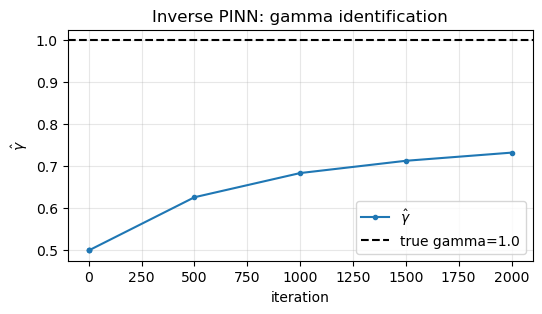

In [8]:
try:
    from burgers_pinn import train_inverse_pinn, GAMMA_INIT_DEFAULT

    GAMMA_INIT = 0.5  # deliberately wrong start; true value is GAMMA=1 in burgers_fdm
    elapsed_inv, hist_inv, u_pinn_inv, gamma_hat = train_inverse_pinn(
        gamma_init=GAMMA_INIT, iters=2000, log_every=500
    )

    print(f'Inverse PINN: gamma_hat={gamma_hat:.4f} (init={GAMMA_INIT}, true={GAMMA})')
    print(f'  time={elapsed_inv:.1f}s, final loss={hist_inv[-1][1]:.6f}')

    # Quick convergence plot: estimated diffusion coefficient vs iteration
    steps = [h[0] for h in hist_inv]
    gammas = [h[2] for h in hist_inv]
    plt.figure(figsize=(6, 3))
    plt.plot(steps, gammas, 'o-', ms=3, label=r'$\hat{\gamma}$')
    plt.axhline(GAMMA, color='k', ls='--', label=f'true gamma={GAMMA}')
    plt.xlabel('iteration')
    plt.ylabel(r'$\hat{\gamma}$')
    plt.title('Inverse PINN: gamma identification')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print('Inverse PINN skip:', e)

## 8. Порівняння


In [9]:
if 'u_pinn' in dir():
    # Compare PINN prediction at t=T with the same reference ue used for FDM
    e_p = u_pinn[:, -1] - ue
    print('PINN vs u*(T): Linf', norm_linf(e_p), 'L2', norm_l2(e_p, H))


PINN vs u*(T): Linf 1.7779797876411245 L2 6.896903516718168
